# Laboratory Day 5a: Edge detection

## 1. Edge detection
**Exercise 1.1 (5 points)**: Sobel Filter
- Load image "circle.png" as a gray-scale image using OpenCV
- Use two Sobel filters to filter this image.

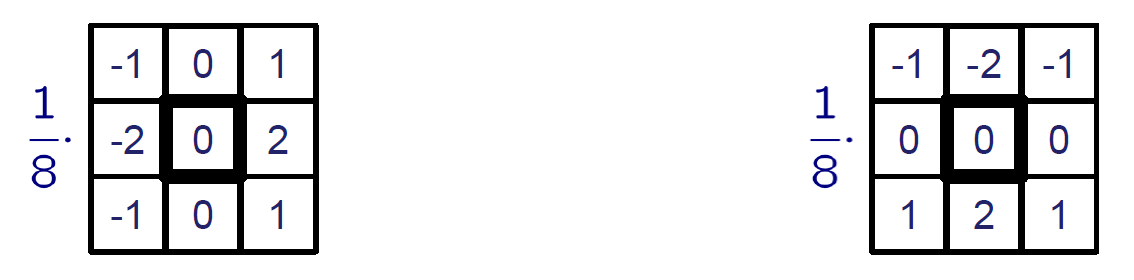


- The results of applying Sobel filters may contain both positive and negative values. To display the result as an image, write a normalization function, which transforms each elements of a np.ndarray to range [0, 255]. The transformation can be mathematically described by:

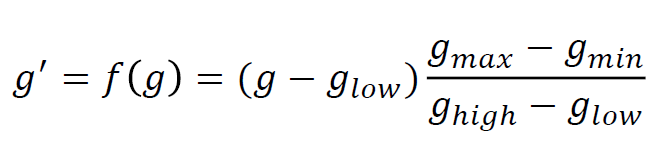

where $g_{min} = 0$, $g_{max}$=255, $g_{low}$ is the smallest value of the np.ndarray, $g_{high}$ is the biggest value  of the np.ndarray. $g_{low}$ and $g_{high}$ can be negative.

- Display the result of applying Sobel filter using the developed normalization function.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

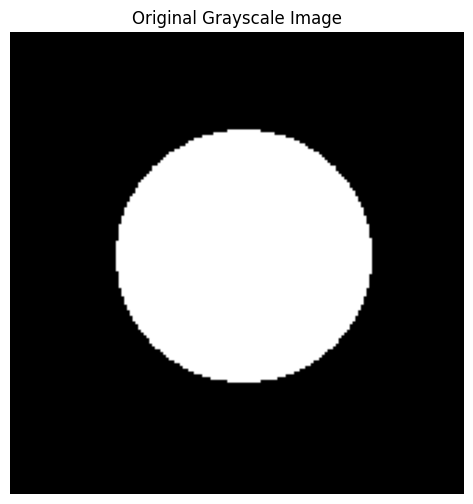

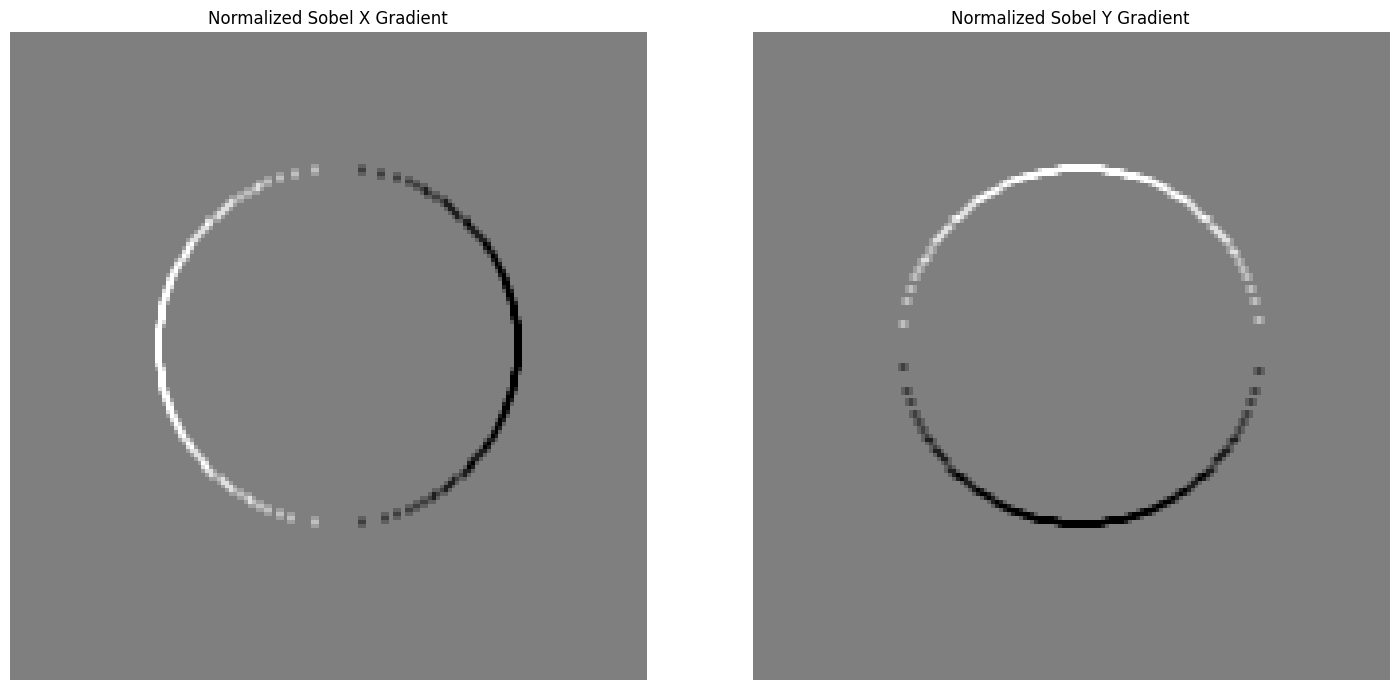

In [8]:
image_path = "c"
# Load image 'circle.png' as grayscale.
img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully.
if img_gray is None:
    print(f"Error: Image at {image_path} could not be loaded.")
else:
    plt.figure(figsize=(6, 6))
    plt.imshow(img_gray, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')
    plt.show()

output_depth = cv2.CV_64F

# Apply Sobel filter for X-gradient.
sobel_x = cv2.Sobel(img_gray, output_depth, 1, 0, ksize=3)

# Apply Sobel filter for Y-gradient.
sobel_y = cv2.Sobel(img_gray, output_depth, 0, 1, ksize=3)

# Normalization function to scale array to [0, 255].
def normalize_image(arr):
    g_low = np.min(arr)
    g_high = np.max(arr)
    g_min = 0
    g_max = 255

    if g_high == g_low:
        return np.full_like(arr, 127, dtype=np.uint8)

    normalized_arr = ((arr - g_low) / (g_high - g_low)) * (g_max - g_min) + g_min
    return np.clip(normalized_arr, 0, 255).astype(np.uint8)

normalized_sobel_x = normalize_image(sobel_x)
normalized_sobel_y = normalize_image(sobel_y)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(normalized_sobel_x, cmap='gray')
plt.title('Normalized Sobel X Gradient')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normalized_sobel_y, cmap='gray')
plt.title('Normalized Sobel Y Gradient')
plt.axis('off')

plt.tight_layout()
plt.show()


**Exercise 1.2 (10 points)**: Laplacian Filter
- Load image "circle.png" as a gray-scale image using OpenCV
- Write a self-implemented function, using the following Laplacian kernel to filter this image. Display the result.
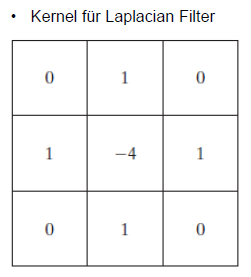

- Call cv2.Laplacian() to filter this image. Display the result.

- Given a 2D np.ndarray, write a detection function, which detects the positions of zero-crossings. The positions of zero-crossing are assigned with value 255. The rest positions are assigned with 0. The positions of zero-crossing can be identified,  if there are both positive and negative values in a given small window.

- Apply this detection function to detect the edge of "circle.png".


Note: To call cv2.Laplacian() one has to specify data types. In cv2, the following data types are defined:

CV_8U - 8-bit unsigned integers ( 0..255 )

CV_8S - 8-bit signed integers ( -128..127 )

CV_16U - 16-bit unsigned integers ( 0..65535 )

CV_16S - 16-bit signed integers ( -32768..32767 )

CV_32S - 32-bit signed integers ( -2147483648..2147483647 )

CV_32F - 32-bit floating-point numbers ( -FLT_MAX..FLT_MAX, INF, NAN )

CV_64F - 64-bit floating-point numbers ( -DBL_MAX..DBL_MAX, INF, NAN )

https://stackoverflow.com/questions/13428689/whats-the-difference-between-cvtype-values-in-opencv

Image loaded for Laplacian processing.


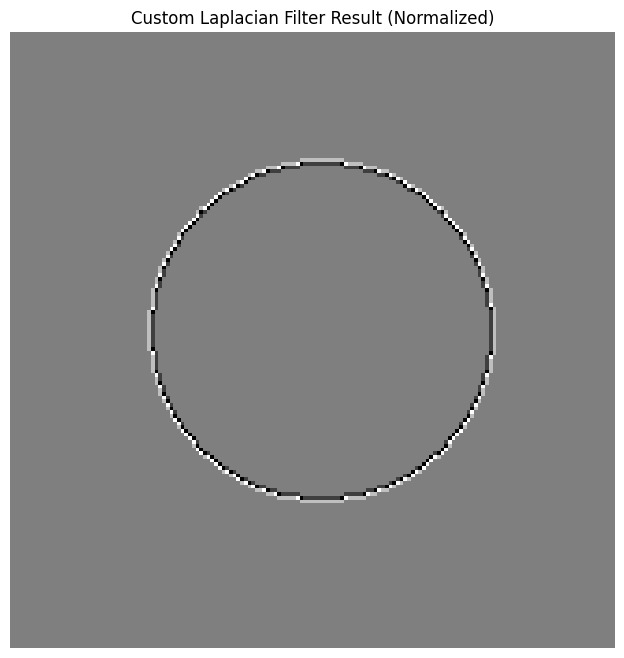

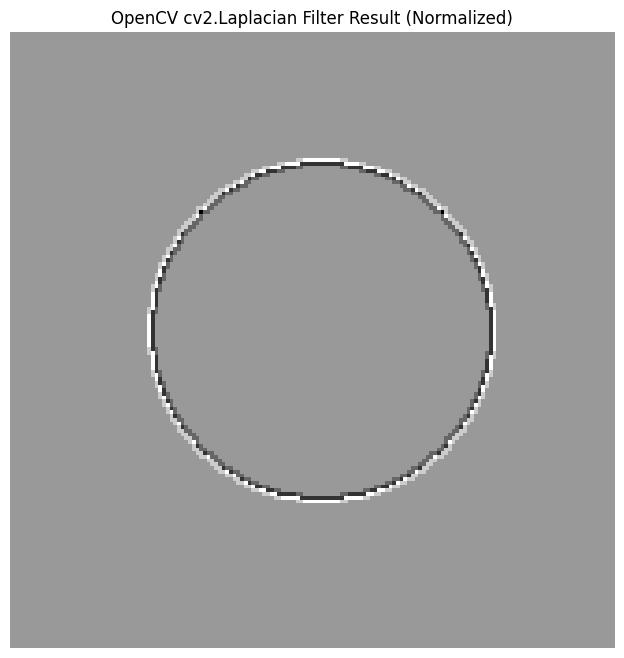

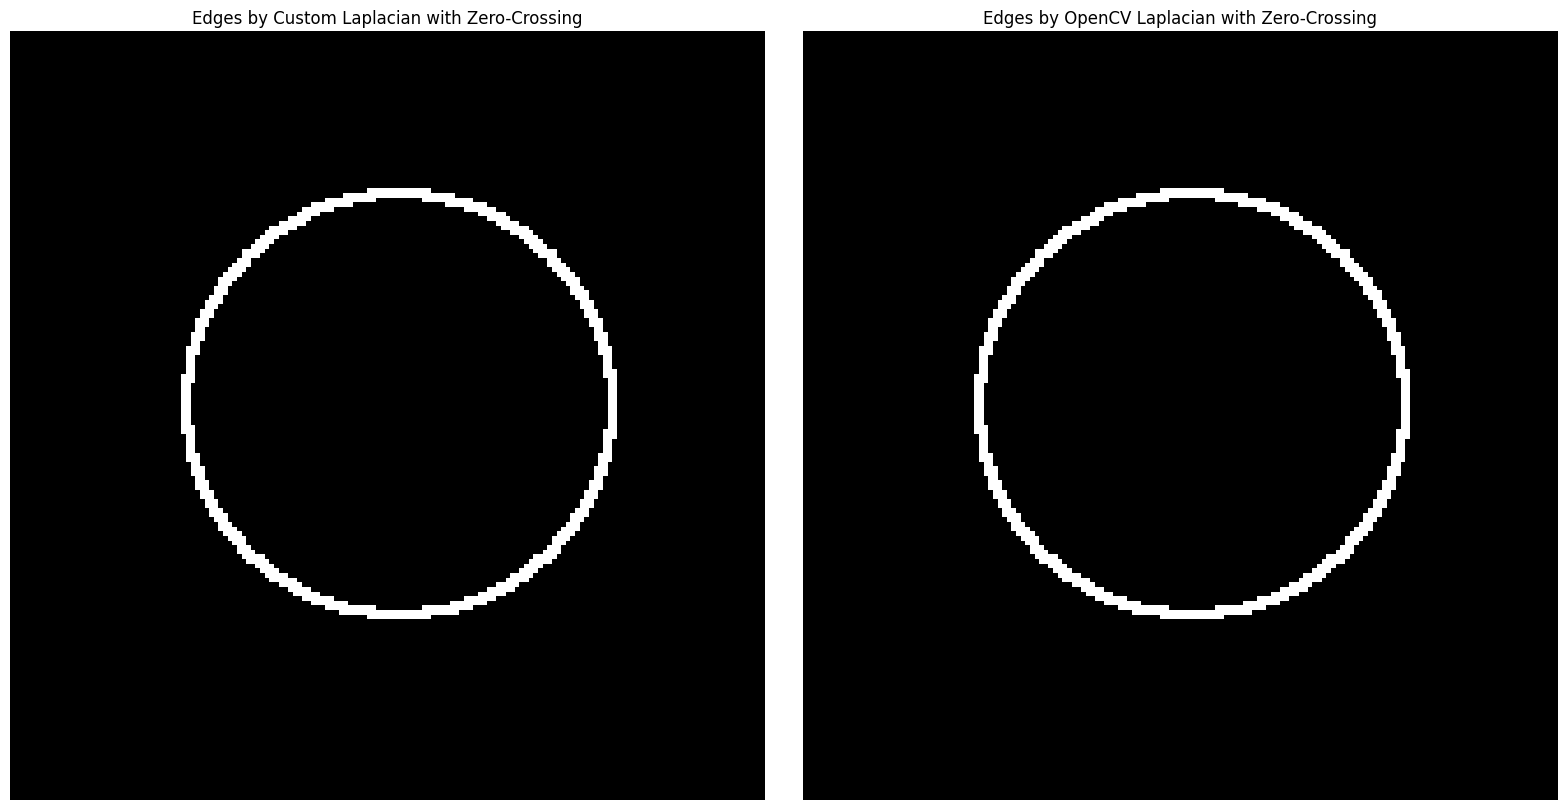

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load image 'circle.png' as grayscale.
img_laplacian = cv2.imread("/circle.png", cv2.IMREAD_GRAYSCALE)

if img_laplacian is None:
    print("Error: 'circle.png' could not be loaded for Laplacian processing. Verify file presence.")
else:
    print("Image loaded for Laplacian processing.")

# Self-implemented Laplacian Filter
def custom_laplacian_filter(image):
    laplacian_kernel = np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ], dtype=np.float32)

    h, w = image.shape
    output_img = np.zeros_like(image, dtype=np.float32)

    kh, kw = laplacian_kernel.shape
    ph = kh // 2
    pw = kw // 2

    padded_img = np.pad(image, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)

    for r in range(h):
        for c in range(w):
            window = padded_img[r : r + kh,
                                c : c + kw]
            output_img[r, c] = np.sum(window * laplacian_kernel)

    return output_img

# Apply custom Laplacian filter
custom_laplacian_result = custom_laplacian_filter(img_laplacian)
normalized_custom_laplacian = normalize_image(custom_laplacian_result)

plt.figure(figsize=(8, 8))
plt.imshow(normalized_custom_laplacian, cmap='gray')
plt.title('Custom Laplacian Filter Result (Normalized)')
plt.axis('off')
plt.show()

# OpenCV's cv2.Laplacian()
opencv_laplacian_result = cv2.Laplacian(img_laplacian, cv2.CV_64F, ksize=3)
normalized_opencv_laplacian = normalize_image(opencv_laplacian_result)

plt.figure(figsize=(8, 8))
plt.imshow(normalized_opencv_laplacian, cmap='gray')
plt.title('OpenCV cv2.Laplacian Filter Result (Normalized)')
plt.axis('off')
plt.show()

# Zero-Crossing Detection Function
def detect_zero_crossings(img_gradient):
    edges = np.zeros_like(img_gradient, dtype=np.uint8)
    h, w = img_gradient.shape

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            neighborhood = img_gradient[y - 1 : y + 2,
                                        x - 1 : x + 2]
            has_pos = np.any(neighborhood > 1e-6)
            has_neg = np.any(neighborhood < -1e-6)

            if has_pos and has_neg:
                edges[y, x] = 255
    return edges

# Apply Zero-Crossing Detection
zero_crossing_custom = detect_zero_crossings(custom_laplacian_result)
zero_crossing_opencv = detect_zero_crossings(opencv_laplacian_result)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(zero_crossing_custom, cmap='gray')
plt.title('Edges by Custom Laplacian with Zero-Crossing')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(zero_crossing_opencv, cmap='gray')
plt.title('Edges by OpenCV Laplacian with Zero-Crossing')
plt.axis('off')

plt.tight_layout()
plt.show()


**Exercise 1.3 (10 points)**: LoG Filter
- Load image "circle.png" as a gray-scale image using OpenCV.

- Write a self-implemented function, which returns the discrete kernel of LoG filter, given kernel size and sigma as two input arguments.

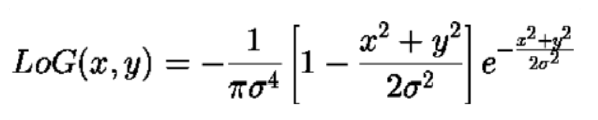

- Use the computed LoG kernel with kernel size = 9 and sigma = 1.4 to filter this image. Display the results of filtering.

- Detect the edges of circle by finding out the positions of zero-crossing.

- Call cv2.GaussianBlur() and cv2.Laplacian() in a sequence to realize the LoG filter. Select proper kernel_size and sigma to detect the circle's edge.

In [ ]:
# Solution

**Exercise 1.4 (5 points)**
- Load "zebra.png" as a gray-scale image
- Tuning the parameters of LoG operation manually and try your best to find the edges in this image. Display the detected edges.


In [ ]:
# Solution